<a href="https://colab.research.google.com/github/WinstonNji/Content-Management-System/blob/main/Content_Moderation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import numpy as np
from numpy import asarray
from numpy import zeros

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os


####### TEXT PREPROCESSING
import re
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')


## TF
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential, regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.feature_extraction.text import TfidfVectorizer

# Imblearn
from imblearn.over_sampling import RandomOverSampler

# Classical Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC , SVC
from sklearn.naive_bayes import MultinomialNB




[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Creating our own labels

In [ ]:
df = pd.read_csv('/content/train.csv')
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [ ]:
df.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [ ]:
df = df.drop(columns=['id'])
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [ ]:
def generate_labels(row):
  if row['toxic'] == 0:
      return 0  # Clean
  elif row['severe_toxic'] == 1 or row['threat'] == 1 or row['identity_hate'] == 1:
      return 2  # Auto-reject
  else:
      return 1  # Flag for review

In [ ]:
df['label'] = df.apply(generate_labels, axis=1)

In [ ]:
df['label'].value_counts()

,count
label,
0,144277
1,12439
2,2855


# Text Standardizing

In [3]:
def preprocess_text(text):
  # 1a Lower
  text = text.lower()

  # 1b Removing special chars
  text = re.sub(r'[^a-z\s]', '', text)

  # 1c tokenization
  token = word_tokenize(text)

  return ' '.join(token)



In [ ]:
df['comment_text'] = df['comment_text'].apply(preprocess_text)

In [ ]:
df['comment_text']

,comment_text
0,explanation why the edits made under my userna...
1,daww he matches this background colour im seem...
2,hey man im really not trying to edit war its j...
3,more i cant make any real suggestions on impro...
4,you sir are my hero any chance you remember wh...
...,...
159566,and for the second time of asking when your vi...
159567,you should be ashamed of yourself that is a ho...
159568,spitzer umm theres no actual article for prost...
159569,and it looks like it was actually you who put ...


# Splitting Dataset

In [ ]:
X = df['comment_text']
y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state = 42,
    test_size=0.2
)

# PHASE 0: NLP

### Helper Function

In [ ]:
def evaluate_model_NLP(model, title, X_vec_test ):
    y_pred = model.predict(X_vec_test)
    print('Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['clean', 'flagged', 'toxic']), '\n')

    print('Accuracy Score:')
    print(accuracy_score(y_test, y_pred), '\n')

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
      cm,
      annot=True,
      fmt = 'd',
      cmap='Blues',
      xticklabels = ['clean', 'flagged', 'toxic'],
      yticklabels = ['clean', 'flagged', 'toxic']
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{title} Confusion Matrix')
    plt.savefig(f"/content/drive/MyDrive/CMS/{title + ' confusion matrix'}.png", dpi=150)
    plt.show()

### TF-IDF vectorization

In [ ]:
vectorizer = TfidfVectorizer(max_features = 20000)
X_vec_train = vectorizer.fit_transform(X_train)
X_vec_test = vectorizer.transform(X_test)

joblib.dump(vectorizer, '/content/drive/MyDrive/CMS/tfidf_vectorizer')

['/content/drive/MyDrive/CMS/tfidf_vectorizer']

In [ ]:
print('Vocab_size', len(vectorizer.vocabulary_))

Vocab_size 20000


### Classical Machine Learning Models

#### MultinomialNB - Baseline Classification Model

In [ ]:
sample_weights = compute_sample_weight(
    class_weight = 'balanced',
    y = y_train
)

model_multinomial_nb = MultinomialNB()
model_multinomial_nb.fit(
    X_vec_train,
    y_train,
    sample_weight = sample_weights
)

MultinomialNB()

Classification Report:
              precision    recall  f1-score   support

       clean       0.99      0.87      0.93     28856
     flagged       0.31      0.65      0.42      2488
       toxic       0.29      0.71      0.41       571

    accuracy                           0.85     31915
   macro avg       0.53      0.75      0.59     31915
weighted avg       0.92      0.85      0.88     31915
 

Accuracy Score:
0.8494751684161053 



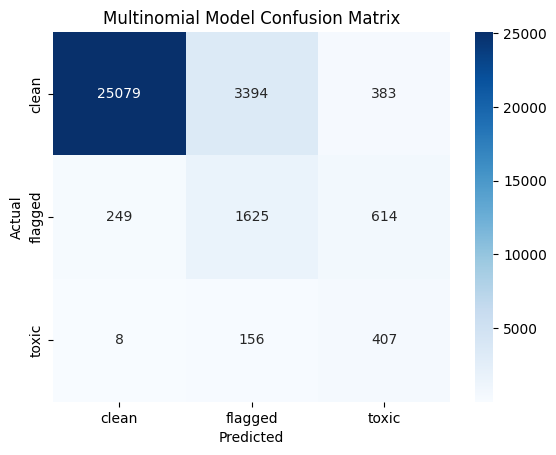

In [ ]:
evaluate_model_NLP(model_multinomial_nb, 'Multinomial Model', X_vec_test)

#### Logistic Regression

In [ ]:
model_logistic_reg = LogisticRegression(class_weight='balanced', max_iter=500)
model_logistic_reg.fit(X_vec_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=500)

Classification Report:
              precision    recall  f1-score   support

       clean       0.99      0.94      0.96     28856
     flagged       0.48      0.71      0.57      2488
       toxic       0.43      0.61      0.50       571

    accuracy                           0.91     31915
   macro avg       0.63      0.75      0.68     31915
weighted avg       0.94      0.91      0.92     31915
 

Accuracy Score:
0.914209619301269 



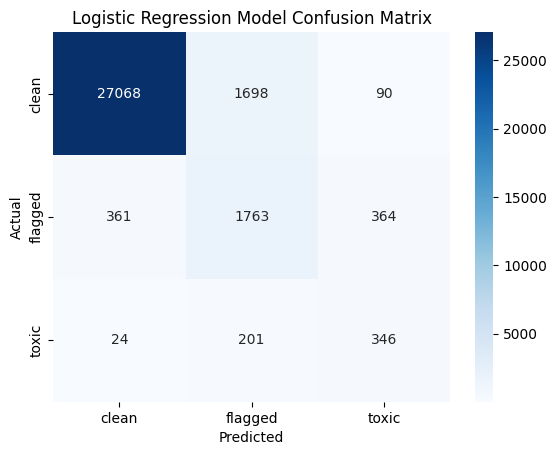

In [ ]:
evaluate_model_NLP(model_logistic_reg, 'Logistic Regression Model', X_vec_test)

#### SVM

In [ ]:
model_linear_svc = LinearSVC(class_weight='balanced', max_iter=500)
model_linear_svc.fit(X_vec_train, y_train)

LinearSVC(class_weight='balanced', max_iter=500)

Classification Report:
              precision    recall  f1-score   support

       clean       0.98      0.98      0.98     28856
     flagged       0.63      0.65      0.64      2488
       toxic       0.46      0.38      0.42       571

    accuracy                           0.94     31915
   macro avg       0.69      0.67      0.68     31915
weighted avg       0.94      0.94      0.94     31915
 

Accuracy Score:
0.939714867617108 



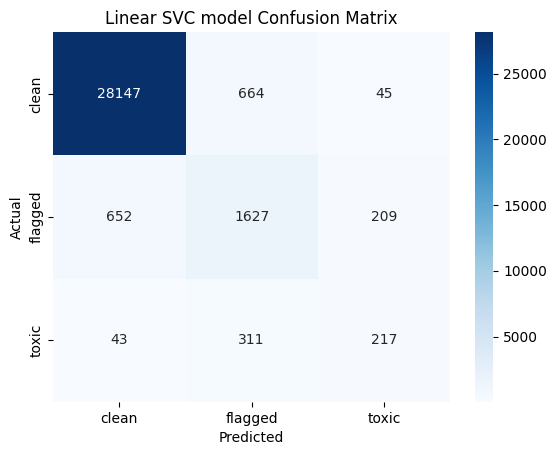

In [ ]:
evaluate_model_NLP(model_linear_svc, 'Linear SVC model', X_vec_test)

##### Non linear SVM

In [ ]:
model_svc = SVC(class_weight='balanced', max_iter=500)
model_svc.fit(X_vec_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(class_weight='balanced', max_iter=500)

Classification Report:
              precision    recall  f1-score   support

       clean       0.00      0.00      0.00     28856
     flagged       0.07      0.76      0.12      2488
       toxic       0.09      0.54      0.15       571

    accuracy                           0.07     31915
   macro avg       0.05      0.43      0.09     31915
weighted avg       0.01      0.07      0.01     31915
 

Accuracy Score:
0.06924643584521385 



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


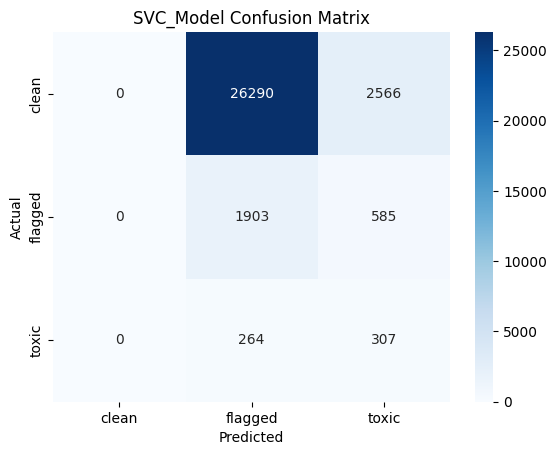

In [ ]:
evaluate_model_NLP(model_svc, 'SVC_Model', X_vec_test)

# Preprocessing for PHASE 1: TF tokenization and padding

In [ ]:
tokenizer = joblib.load('/content/tokenizer.joblib')

In [ ]:
# tokenizer = Tokenizer(num_words = 20000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=200, truncating='post', padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=200, truncating='post', padding = 'post')


In [ ]:
joblib.dump(tokenizer, '/content/drive/MyDrive/CMS/tokenizer.joblib')

['/content/drive/MyDrive/CMS/tokenizer.joblib']

# Helper functions for training and Evaluation

In [ ]:
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=6, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, min_lr=1e-6, patience=4, verbose=1)
    ]

def plot_training(history, title):
  fig, ax = plt.subplots(1,2, figsize = (12,4))

  ax[0].plot(history.history['loss'], label = 'Training loss', linestyle='--')
  ax[0].plot(history.history['val_loss'], label = 'Validation loss')
  ax[0].legend()
  ax[0].set_title('Training loss Vs Validation loss')
  ax[0].set_ylabel('Loss')
  ax[0].set_xlabel('Epochs')
  ax[0].grid()

  ax[1].plot(history.history['accuracy'], label = 'Training Accuracy', linestyle='--')
  ax[1].plot(history.history['val_accuracy'], label = 'Validation Accuracy')
  ax[1].legend()
  ax[1].set_title('Training Accuracy  Vs Validation Accuracy')
  ax[1].set_ylabel('Accuracy')
  ax[1].set_xlabel('Epochs')
  ax[1].grid()

  plt.suptitle(title)
  plt.tight_layout()
  plt.savefig(f'/content/drive/MyDrive/CMS/{title}.png', dpi=150)
  plt.show()

def evaluate_model(model, title):
    y_pred = np.argmax(model.predict(X_test_padded), axis=1)
    print('Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['clean', 'flagged', 'toxic']), '\n')

    print('Accuracy Score:')
    print(accuracy_score(y_test, y_pred), '\n')

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
      cm,
      annot=True,
      fmt = 'd',
      cmap='Blues',
      xticklabels = ['clean', 'flagged', 'toxic'],
      yticklabels = ['clean', 'flagged', 'toxic']
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{title} Confusion Matrix')
    plt.savefig(f"/content/drive/MyDrive/CMS/{title + ' confusion matrix'}.png", dpi=150)
    plt.show()



In [ ]:
def save_model(model, name):
  model.save(f'/content/drive/MyDrive/CMS/{name}.keras')

# PHASE 1 - BASELINE MODEL: LSTM

In [ ]:
model_v0 = Sequential([
    layers.Embedding(
        input_dim = 20000,
        output_dim = 128,
        input_length = 200
    ),

    layers.LSTM(
        64,
    ),

    layers.Dense(
        3,
        activation = 'softmax'
    )
])

model_v0.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history_v0 = model_v0.fit(
    X_train_padded,
    y_train,
    epochs = 25,
    batch_size = 64,
    validation_split=.2,
    callbacks = get_callbacks(),
    verbose = 1
)

Epoch 1/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9050 - loss: 0.3560 - val_accuracy: 0.9172 - val_loss: 0.2501 - learning_rate: 0.0010
Epoch 2/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9409 - loss: 0.1700 - val_accuracy: 0.9418 - val_loss: 0.1595 - learning_rate: 0.0010
Epoch 3/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9525 - loss: 0.1224 - val_accuracy: 0.9406 - val_loss: 0.1550 - learning_rate: 0.0010
Epoch 4/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9597 - loss: 0.1014 - val_accuracy: 0.9391 - val_loss: 0.1684 - learning_rate: 0.0010
Epoch 5/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9678 - loss: 0.0810 - val_accuracy: 0.9384 - val_loss: 0.1929 - learning_rate: 0.0010
Epoch 6/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9756 - loss: 0.0647 - val_accuracy: 0.9320 - val_loss: 0.2161 - learning_rate: 0.0010
Epoch 7/25
1595/1596 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accurac

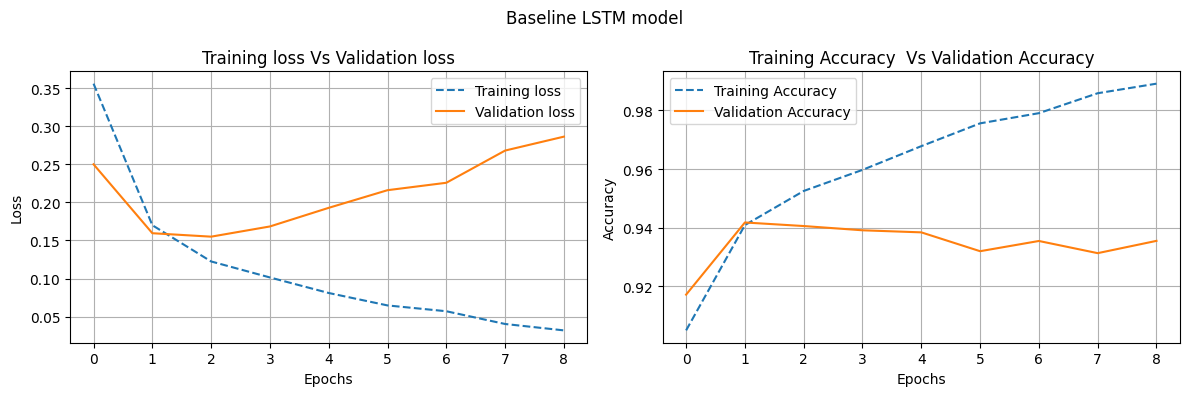

In [ ]:
plot_training(history_v0, 'Baseline LSTM model')

998/998 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
Classification Report:
              precision    recall  f1-score   support

       clean       0.97      0.98      0.98     28856
     flagged       0.64      0.70      0.67      2488
       toxic       0.62      0.05      0.10       571

    accuracy                           0.94     31915
   macro avg       0.74      0.58      0.58     31915
weighted avg       0.94      0.94      0.94     31915
 

Accuracy Score:
0.9441955193482688 



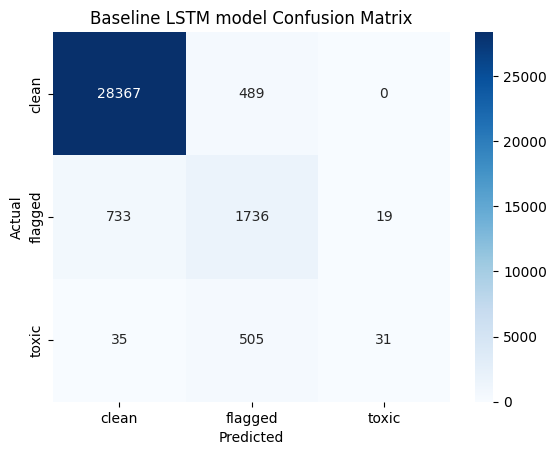

In [ ]:
evaluate_model(model_v0, 'Baseline LSTM model')

In [ ]:
save_model(model_v0, 'model_v0')

## Evaluation

The baseline models has an accuracy of 94% but this is primarily driven by the models abilitiy to recall and precisely identify clean texts.

There is a huge class inbalance in our dataset, which leads to varying results espxailly when we look at recall.

Our model is has a recall of 98% for clean class which is the most common class and is able to precisely identify clean classes with a precision of 95%

For flagged class our model has a recall of 70%, misses over 30% of messages that should be flagged. with a precision of 64% on indentified flagged our model lacks precision.

Toxic is where our models difficulties are really visible. Our model barely recalls toxic class, primarily due to class imbalance which doesn't expose our model to enough inbalanced class for it to be able to really draw them our.

The macro average of 58 highlights our model inability to treat all classes equally

# Phase 2 — Class Balancing

We'll evaluate which class balancing approach is best for our dataset. ClassWeight or ROS (Random Over Sampler)

## Class Weight Balancing

In [ ]:
class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(y_train),
    y = y_train
)

In [ ]:
class_weights_dict = dict(enumerate(class_weights))

In [ ]:
class_weights_dict

{0: np.float64(0.3686677467705184),
 1: np.float64(4.276153150437142),
 2: np.float64(18.63047285464098)}

In [ ]:
model_v1_cw = Sequential([
    layers.Embedding(
        input_dim = 20000,
        output_dim = 128,
        input_length = 200
    ),

    layers.LSTM(
        64,
    ),

    layers.Dense(
        3,
        activation = 'softmax'
    )
])

model_v1_cw.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history_v1_cw = model_v1_cw.fit(
    X_train_padded,
    y_train,
    epochs = 25,
    batch_size = 64,
    validation_split=.2,
    callbacks = get_callbacks(),
    verbose = 1,
    class_weight = class_weights_dict
)

Epoch 1/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.3369 - loss: 1.0783 - val_accuracy: 0.0715 - val_loss: 1.1226 - learning_rate: 0.0010
Epoch 2/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.2620 - loss: 1.0533 - val_accuracy: 0.8976 - val_loss: 0.9641 - learning_rate: 0.0010
Epoch 3/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.3436 - loss: 1.0216 - val_accuracy: 0.7757 - val_loss: 0.6862 - learning_rate: 0.0010
Epoch 4/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.8575 - loss: 0.6348 - val_accuracy: 0.8941 - val_loss: 0.2832 - learning_rate: 0.0010
Epoch 5/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.8971 - loss: 0.4506 - val_accuracy: 0.8982 - val_loss: 0.2676 - learning_rate: 0.0010
Epoch 6/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9197 - loss: 0.3392 - val_accuracy: 0.8847 - val_loss: 0.3037 - learning_rate: 0.0010
Epoch 7/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accura

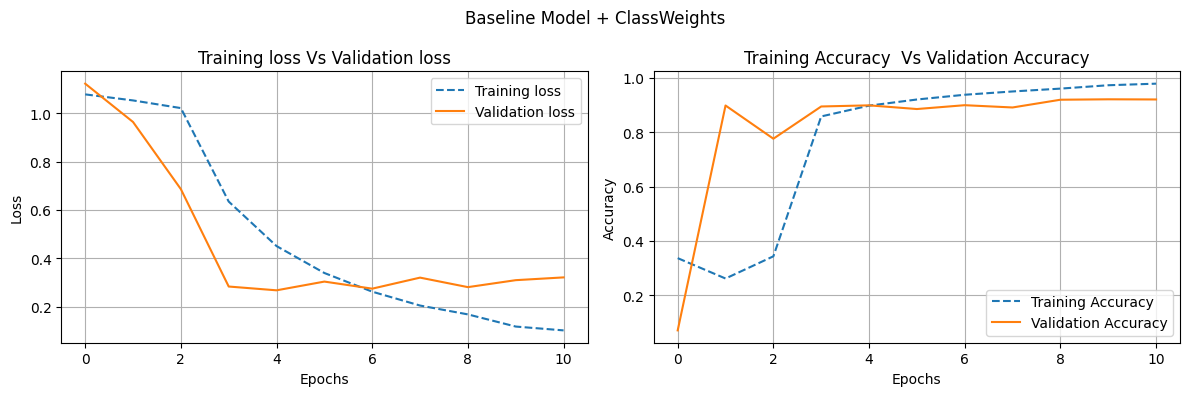

In [ ]:
plot_training(history_v1_cw, 'Baseline Model + ClassWeights')

998/998 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
Classification Report:
              precision    recall  f1-score   support

       clean       0.99      0.93      0.96     28856
     flagged       0.42      0.63      0.51      2488
       toxic       0.42      0.72      0.53       571

    accuracy                           0.90     31915
   macro avg       0.61      0.76      0.66     31915
weighted avg       0.93      0.90      0.91     31915
 

Accuracy Score:
0.9027729907566975 



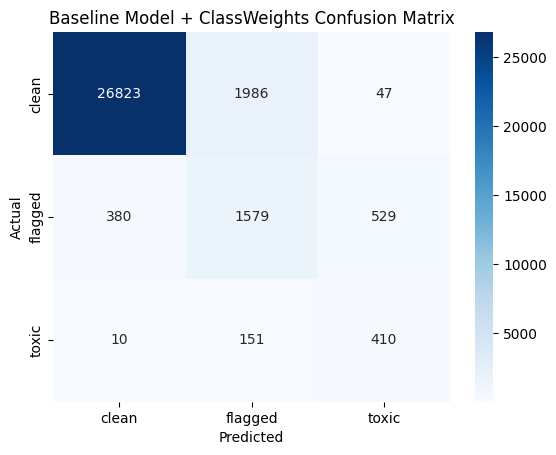

In [ ]:
evaluate_model(model_v1_cw, 'Baseline Model + ClassWeights')

In [ ]:
save_model(model_v1_cw, 'model_v1_cw')

### Evaluation

Althrough recall reduce for clean , precision drastically increased.
Flagged recall and precision was the most affected, seing drastic reduction in both
Improvement in recall but drop in toxic precision


## Random OverSampler

In [ ]:
y_train.value_counts()

,count
label,
0,115421
1,9951
2,2284


In [ ]:
ros = RandomOverSampler()
X_train_res, y_train_res = ros.fit_resample(X_train_padded,y_train)

In [ ]:
model_v1_ros = Sequential([
    layers.Embedding(
        input_dim = 20000,
        output_dim = 128,
        input_length = 200
    ),

    layers.LSTM(
        64,
    ),

    layers.Dense(
        3,
        activation = 'softmax'
    )
])

model_v1_ros.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history_v1_ros = model_v1_ros.fit(
    X_train_res,
    y_train_res,
    epochs = 25,
    batch_size = 64,
    validation_split=.2,
    callbacks = get_callbacks(),
    verbose = 1
)

Epoch 1/25
4329/4329 ━━━━━━━━━━━━━━━━━━━━ 77s 17ms/step - accuracy: 0.6471 - loss: 0.6915 - val_accuracy: 0.7712 - val_loss: 0.6416 - learning_rate: 0.0010
Epoch 2/25
4329/4329 ━━━━━━━━━━━━━━━━━━━━ 62s 14ms/step - accuracy: 0.9404 - loss: 0.1868 - val_accuracy: 0.9033 - val_loss: 0.3129 - learning_rate: 0.0010
Epoch 3/25
4329/4329 ━━━━━━━━━━━━━━━━━━━━ 93s 17ms/step - accuracy: 0.9733 - loss: 0.0935 - val_accuracy: 0.9795 - val_loss: 0.0761 - learning_rate: 0.0010
Epoch 4/25
4329/4329 ━━━━━━━━━━━━━━━━━━━━ 60s 14ms/step - accuracy: 0.9839 - loss: 0.0584 - val_accuracy: 0.9862 - val_loss: 0.0568 - learning_rate: 0.0010
Epoch 5/25
4329/4329 ━━━━━━━━━━━━━━━━━━━━ 63s 15ms/step - accuracy: 0.9887 - loss: 0.0400 - val_accuracy: 0.9802 - val_loss: 0.0529 - learning_rate: 0.0010
Epoch 6/25
4329/4329 ━━━━━━━━━━━━━━━━━━━━ 60s 14ms/step - accuracy: 0.9921 - loss: 0.0283 - val_accuracy: 0.9912 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 7/25
4329/4329 ━━━━━━━━━━━━━━━━━━━━ 60s 14ms/step - accura

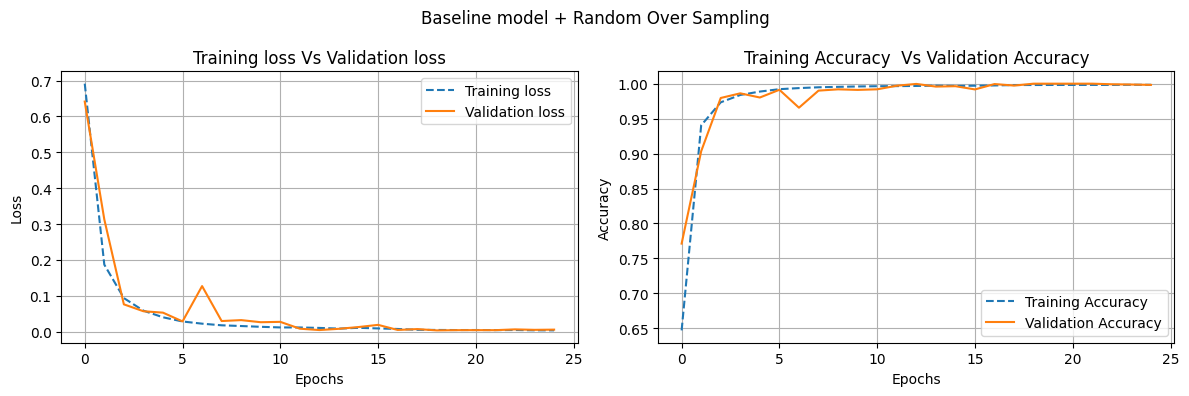

In [ ]:
plot_training(history_v1_ros, 'Baseline model + Random Over Sampling')

998/998 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
Classification Report:
              precision    recall  f1-score   support

       clean       0.96      0.98      0.97     28856
     flagged       0.63      0.49      0.55      2488
       toxic       0.48      0.38      0.43       571

    accuracy                           0.93     31915
   macro avg       0.69      0.62      0.65     31915
weighted avg       0.93      0.93      0.93     31915
 

Accuracy Score:
0.9344508851637161 



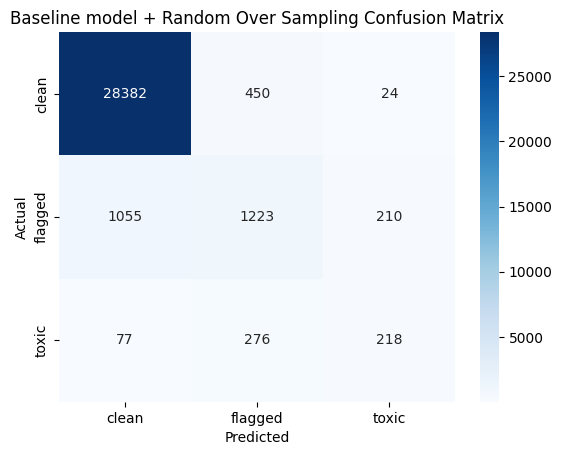

In [ ]:
evaluate_model(model_v1_ros,'Baseline model + Random Over Sampling')

In [ ]:
save_model(model_v1_ros, 'model_v1_ros')

### Evaluation

ROS has performed worsed than CW. Although it has performed better than our baseline model. It still misses a lot of toxic, and is ale to identify 200 less toxic comments than our CW model. Increase overall size of our model equally mad training alot longer and more computationaly demanding.

# PHASE 3

## LSTM experiments

### Single Layer LSTM with dropout (0.3)

In [ ]:
model_v2_lstm_dropout = Sequential([
    layers.Embedding(
        input_dim = 20000,
        output_dim = 128,
        input_length = 200
    ),

    layers.LSTM(
        64,
    ),

    layers.Dropout(0.3),

    layers.Dense(
        3,
        activation = 'softmax'
    )
])

model_v2_lstm_dropout.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history_v2_lstm_dropout = model_v2_lstm_dropout.fit(
    X_train_padded,
    y_train,
    epochs = 25,
    batch_size = 64,
    validation_split=.2,
    callbacks = get_callbacks(),
    verbose = 1,
    class_weight = class_weights_dict
)

Epoch 1/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.3107 - loss: 1.0793 - val_accuracy: 0.1358 - val_loss: 1.0065 - learning_rate: 0.0010
Epoch 2/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.2624 - loss: 1.0592 - val_accuracy: 0.1347 - val_loss: 1.0373 - learning_rate: 0.0010
Epoch 3/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 57s 24ms/step - accuracy: 0.5000 - loss: 0.9447 - val_accuracy: 0.8418 - val_loss: 0.4381 - learning_rate: 0.0010
Epoch 4/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.8659 - loss: 0.5830 - val_accuracy: 0.8901 - val_loss: 0.3056 - learning_rate: 0.0010
Epoch 5/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9014 - loss: 0.4378 - val_accuracy: 0.8763 - val_loss: 0.3360 - learning_rate: 0.0010
Epoch 6/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.9242 - loss: 0.3357 - val_accuracy: 0.8897 - val_loss: 0.2929 - learning_rate: 0.0010
Epoch 7/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accura

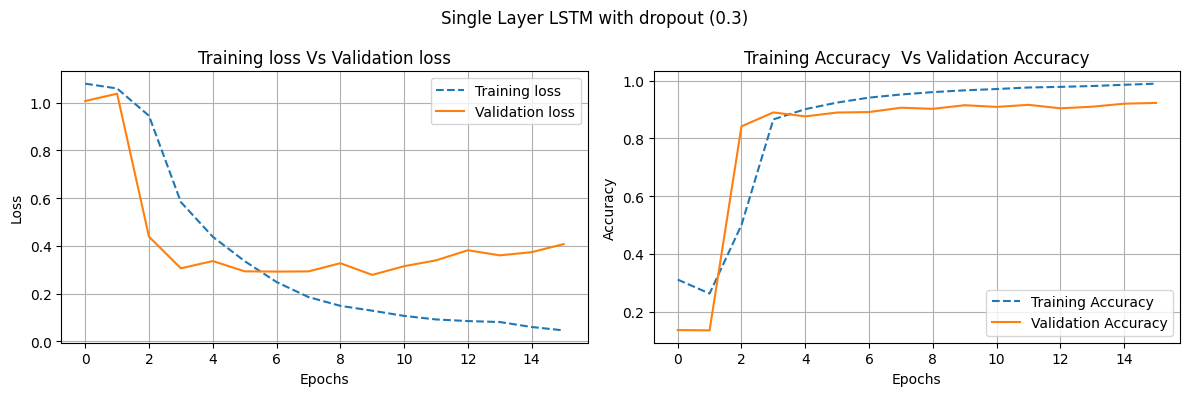

In [ ]:
plot_training(
    history_v2_lstm_dropout,
    'Single Layer LSTM with dropout (0.3)'
)

998/998 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
Classification Report:
              precision    recall  f1-score   support

       clean       0.98      0.95      0.96     28856
     flagged       0.49      0.62      0.55      2488
       toxic       0.41      0.57      0.48       571

    accuracy                           0.92     31915
   macro avg       0.63      0.71      0.66     31915
weighted avg       0.93      0.92      0.92     31915
 

Accuracy Score:
0.917248942503525 



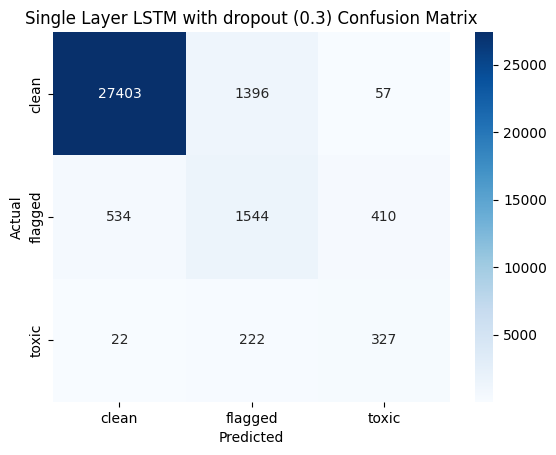

In [ ]:
evaluate_model(model_v2_lstm_dropout, 'Single Layer LSTM with dropout (0.3)')

In [ ]:
save_model(model_v2_lstm_dropout, 'model_v2_lstm_dropout')

### Single Layer LSTM with Dropout and L2 regularization

In [ ]:
model_v2_lstm_dropout_l2 = Sequential([
    layers.Embedding(
        input_dim = 20000,
        output_dim = 128,
        input_length = 200
    ),

    layers.LSTM(
        64,
        kernel_regularizer = regularizers.L2(0.001),
        recurrent_regularizer=regularizers.L2(0.001)
    ),

    layers.Dropout(0.3),

    layers.Dense(
        3,
        activation = 'softmax'
    )
])

model_v2_lstm_dropout_l2.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history_v2_lstm_dropout_l2 = model_v2_lstm_dropout_l2.fit(
    X_train_padded,
    y_train,
    epochs = 25,
    batch_size = 64,
    validation_split=.2,
    callbacks = get_callbacks(),
    verbose = 1,
    class_weight = class_weights_dict
)

Epoch 1/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.3463 - loss: 1.0968 - val_accuracy: 0.1379 - val_loss: 1.1069 - learning_rate: 0.0010
Epoch 2/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.3686 - loss: 1.0735 - val_accuracy: 0.1431 - val_loss: 1.0412 - learning_rate: 0.0010
Epoch 3/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.3723 - loss: 1.0670 - val_accuracy: 0.0763 - val_loss: 1.1264 - learning_rate: 0.0010
Epoch 4/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.3499 - loss: 1.0583 - val_accuracy: 0.8930 - val_loss: 0.9545 - learning_rate: 0.0010
Epoch 5/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.2984 - loss: 1.0603 - val_accuracy: 0.1448 - val_loss: 1.0171 - learning_rate: 0.0010
Epoch 6/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.3270 - loss: 1.0605 - val_accuracy: 0.1445 - val_loss: 1.0671 - learning_rate: 0.0010
Epoch 7/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 42s 15ms/step - accura

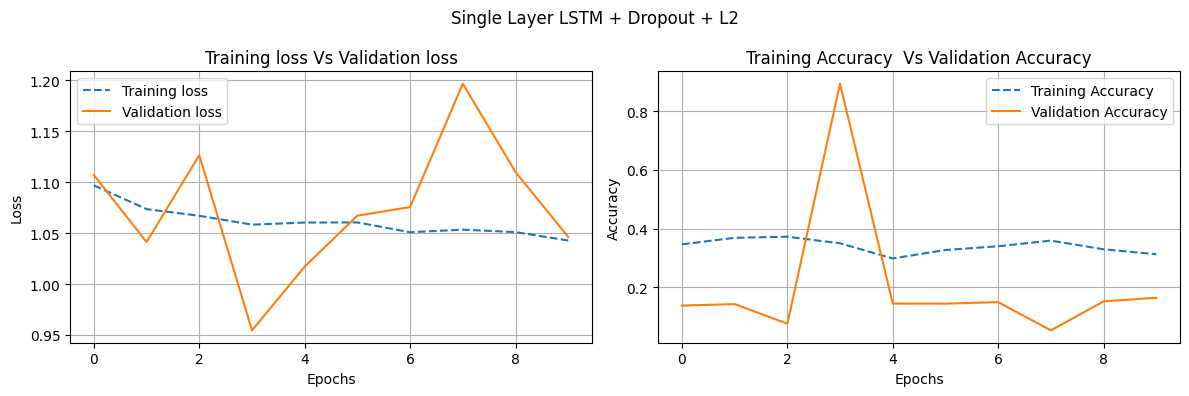

In [ ]:
plot_training(history_v2_lstm_dropout_l2, 'Single Layer LSTM + Dropout + L2')

998/998 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
Classification Report:
              precision    recall  f1-score   support

       clean       0.91      0.99      0.95     28856
     flagged       0.08      0.01      0.02      2488
       toxic       0.61      0.04      0.08       571

    accuracy                           0.90     31915
   macro avg       0.53      0.35      0.35     31915
weighted avg       0.84      0.90      0.86     31915
 

Accuracy Score:
0.8962556791477362 



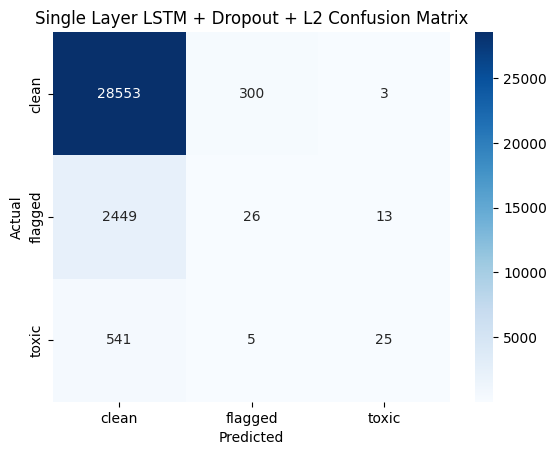

In [ ]:
evaluate_model(model_v2_lstm_dropout_l2, 'Single Layer LSTM + Dropout + L2')

In [ ]:
save_model(model_v2_lstm_dropout_l2, 'model_v2_lstm_dropout_l2')

#### Evaluation

L2 at this strength kills minority class detection, and combined with dropout it's too much regularization for a single 64-unit LSTM.

### Stacked LSTM

In [ ]:
model_v2_stacked_lstm = Sequential([
    layers.Embedding(
        input_dim=20000,
        output_dim=128,
        input_length=200
    ),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(64),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model_v2_stacked_lstm.compile(
  optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [ ]:
history_v2_stacked_lstm = model_v2_stacked_lstm.fit(
    X_train_padded,
    y_train,
    epochs = 25,
    batch_size = 64,
    validation_split=.2,
    callbacks = get_callbacks(),
    verbose = 1,
    class_weight = class_weights_dict
)

Epoch 1/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 74s 43ms/step - accuracy: 0.3173 - loss: 1.0796 - val_accuracy: 0.1478 - val_loss: 1.0456 - learning_rate: 0.0010
Epoch 2/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.4870 - loss: 1.0095 - val_accuracy: 0.8999 - val_loss: 0.9915 - learning_rate: 0.0010
Epoch 3/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.6130 - loss: 0.9175 - val_accuracy: 0.8097 - val_loss: 0.5993 - learning_rate: 0.0010
Epoch 4/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.8066 - loss: 0.7033 - val_accuracy: 0.8316 - val_loss: 0.4566 - learning_rate: 0.0010
Epoch 5/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.8810 - loss: 0.5128 - val_accuracy: 0.9119 - val_loss: 0.2283 - learning_rate: 0.0010
Epoch 6/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.9037 - loss: 0.4194 - val_accuracy: 0.8941 - val_loss: 0.2712 - learning_rate: 0.0010
Epoch 7/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accura

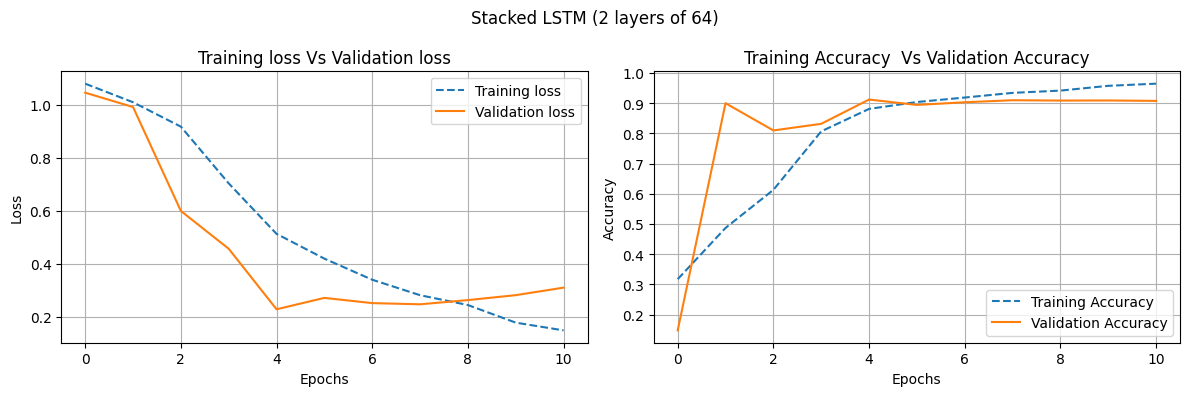

In [ ]:
plot_training(history_v2_stacked_lstm, 'Stacked LSTM (2 layers of 64)')

998/998 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
Classification Report:
              precision    recall  f1-score   support

       clean       0.98      0.94      0.96     28856
     flagged       0.47      0.67      0.55      2488
       toxic       0.48      0.67      0.56       571

    accuracy                           0.91     31915
   macro avg       0.65      0.76      0.69     31915
weighted avg       0.94      0.91      0.92     31915
 

Accuracy Score:
0.9146796177346076 



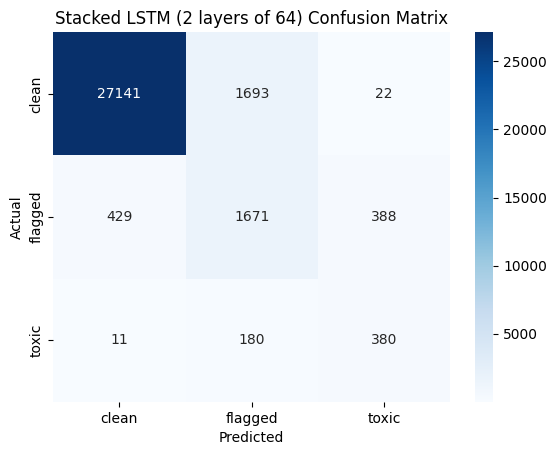

In [ ]:
evaluate_model(model_v2_stacked_lstm, 'Stacked LSTM (2 layers of 64)')

In [ ]:
save_model(model_v2_stacked_lstm, 'model_v2_stacked_lstm')

### STACKED LSTM FUNNEL

In [ ]:
model_v2_stacked_lstm_funnel = Sequential([
    layers.Embedding(
        input_dim=20000,
        output_dim=128,
        input_length=200
    ),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(32),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model_v2_stacked_lstm_funnel.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history_v2_stacked_lstm_funnel = model_v2_stacked_lstm_funnel.fit(
    X_train_padded,
    y_train,
    epochs = 25,
    batch_size = 64,
    validation_split=.2,
    callbacks = get_callbacks(),
    verbose = 1,
    class_weight = class_weights_dict
)

Epoch 1/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.2892 - loss: 1.0820 - val_accuracy: 0.0859 - val_loss: 1.2213 - learning_rate: 0.0010
Epoch 2/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.6265 - loss: 1.0560 - val_accuracy: 0.8881 - val_loss: 0.9956 - learning_rate: 0.0010
Epoch 3/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.8807 - loss: 1.0187 - val_accuracy: 0.8813 - val_loss: 0.9694 - learning_rate: 0.0010
Epoch 4/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 49s 30ms/step - accuracy: 0.6098 - loss: 1.0617 - val_accuracy: 0.9006 - val_loss: 1.0881 - learning_rate: 0.0010
Epoch 5/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.7046 - loss: 1.0331 - val_accuracy: 0.7554 - val_loss: 0.9869 - learning_rate: 0.0010
Epoch 6/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.7646 - loss: 1.0239 - val_accuracy: 0.7778 - val_loss: 1.0236 - learning_rate: 0.0010
Epoch 7/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accura

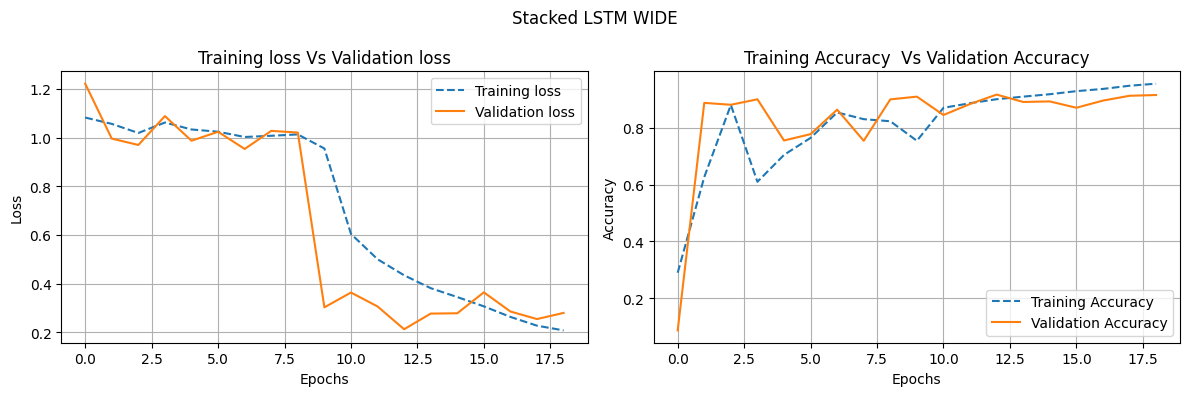

In [ ]:
plot_training(history_v2_stacked_lstm_funnel, 'Stacked LSTM WIDE')

998/998 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step
Classification Report:
              precision    recall  f1-score   support

       clean       0.98      0.95      0.97     28856
     flagged       0.50      0.64      0.56      2488
       toxic       0.45      0.70      0.55       571

    accuracy                           0.92     31915
   macro avg       0.65      0.76      0.69     31915
weighted avg       0.94      0.92      0.93     31915
 

Accuracy Score:
0.9218235939213536 



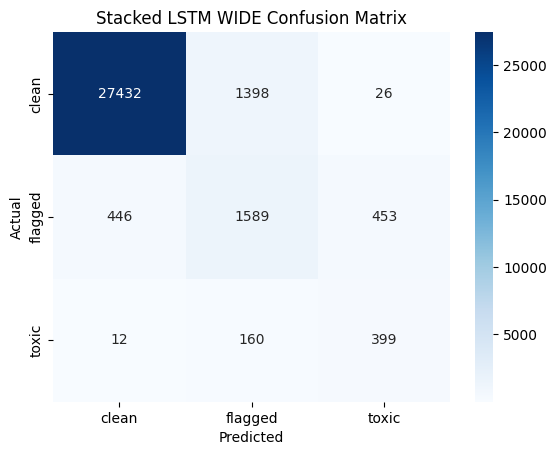

In [ ]:
evaluate_model(model_v2_stacked_lstm_funnel, 'Stacked LSTM WIDE')

In [ ]:
save_model(model_v2_stacked_lstm_funnel, 'model_v2_stacked_lstm_funnel')

## GRU Experiments

### GRU + Dropout (0.3)

In [ ]:
model_v2_GRU_dropout = Sequential([
    layers.Embedding(
        input_dim = 20000,
        output_dim = 128,
        input_length = 200
    ),

    layers.GRU(
        64,
    ),

    layers.Dropout(0.3),

    layers.Dense(
        3,
        activation = 'softmax'
    )
])

model_v2_GRU_dropout.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history_v2_GRU_dropout = model_v2_GRU_dropout.fit(
    X_train_padded,
    y_train,
    epochs = 25,
    batch_size = 64,
    validation_split=.2,
    callbacks = get_callbacks(),
    verbose = 1,
    class_weight = class_weights_dict
)

Epoch 1/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.3470 - loss: 1.0821 - val_accuracy: 0.1429 - val_loss: 1.0445 - learning_rate: 0.0010
Epoch 2/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.3767 - loss: 1.0529 - val_accuracy: 0.8472 - val_loss: 0.5313 - learning_rate: 0.0010
Epoch 3/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - accuracy: 0.8565 - loss: 0.5921 - val_accuracy: 0.8805 - val_loss: 0.3221 - learning_rate: 0.0010
Epoch 4/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9070 - loss: 0.4119 - val_accuracy: 0.9107 - val_loss: 0.2317 - learning_rate: 0.0010
Epoch 5/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9315 - loss: 0.2989 - val_accuracy: 0.8947 - val_loss: 0.2831 - learning_rate: 0.0010
Epoch 6/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9481 - loss: 0.2114 - val_accuracy: 0.9007 - val_loss: 0.2800 - learning_rate: 0.0010
Epoch 7/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accura

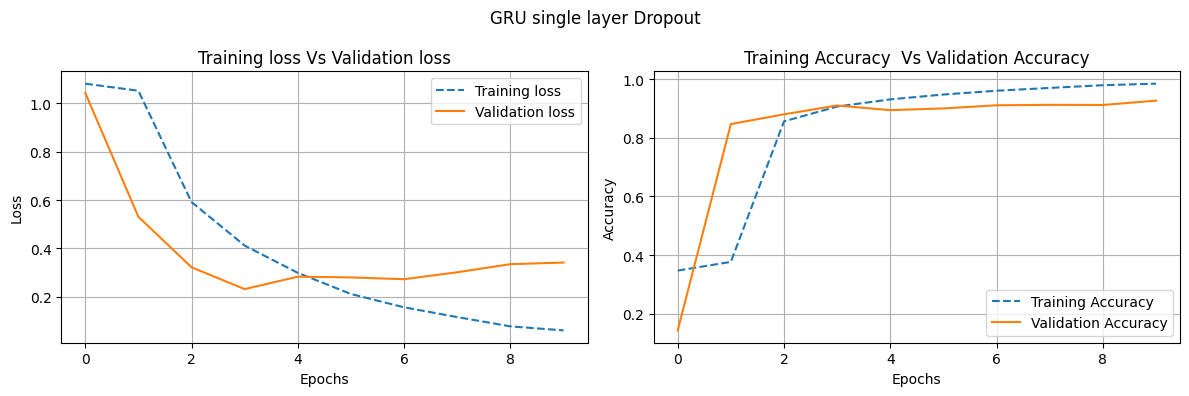

In [ ]:
plot_training(history_v2_GRU_dropout, 'GRU single layer Dropout')

998/998 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
Classification Report:
              precision    recall  f1-score   support

       clean       0.99      0.94      0.96     28856
     flagged       0.47      0.67      0.55      2488
       toxic       0.45      0.70      0.55       571

    accuracy                           0.91     31915
   macro avg       0.64      0.77      0.69     31915
weighted avg       0.94      0.91      0.92     31915
 

Accuracy Score:
0.9134889550368166 



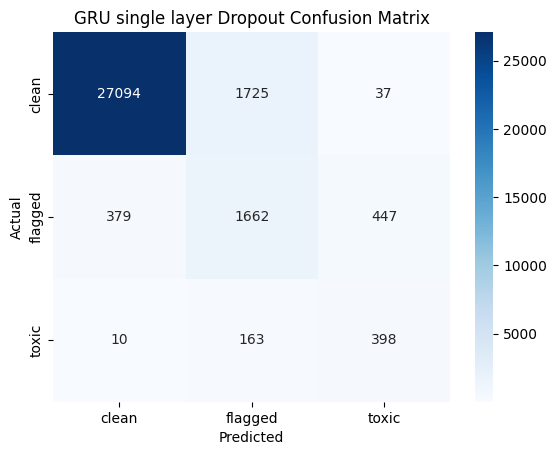

In [ ]:
evaluate_model(model_v2_GRU_dropout, 'GRU single layer Dropout')

In [ ]:
save_model(model_v2_GRU_dropout, 'model_v2_GRU_dropout')

### Stacked GRU

In [ ]:
model_v2_stacked_GRU = Sequential([
    layers.Embedding(
        input_dim=20000,
        output_dim=128,
        input_length=200
    ),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(64),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model_v2_stacked_GRU.compile(
  optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history_v2_stacked_GRU = model_v2_stacked_GRU.fit(
    X_train_padded,
    y_train,
    epochs = 25,
    batch_size = 64,
    validation_split=.2,
    callbacks = get_callbacks(),
    verbose = 1,
    class_weight = class_weights_dict
)

Epoch 1/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 66s 39ms/step - accuracy: 0.5791 - loss: 1.0183 - val_accuracy: 0.7251 - val_loss: 0.9597 - learning_rate: 0.0010
Epoch 2/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 60s 25ms/step - accuracy: 0.6700 - loss: 0.9504 - val_accuracy: 0.8491 - val_loss: 1.1073 - learning_rate: 0.0010
Epoch 3/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.4839 - loss: 0.9799 - val_accuracy: 0.8252 - val_loss: 0.5087 - learning_rate: 0.0010
Epoch 4/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.8629 - loss: 0.5826 - val_accuracy: 0.8958 - val_loss: 0.2668 - learning_rate: 0.0010
Epoch 5/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 37s 22ms/step - accuracy: 0.9009 - loss: 0.4275 - val_accuracy: 0.9009 - val_loss: 0.2663 - learning_rate: 0.0010
Epoch 6/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.9176 - loss: 0.3299 - val_accuracy: 0.8960 - val_loss: 0.2691 - learning_rate: 0.0010
Epoch 7/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accura

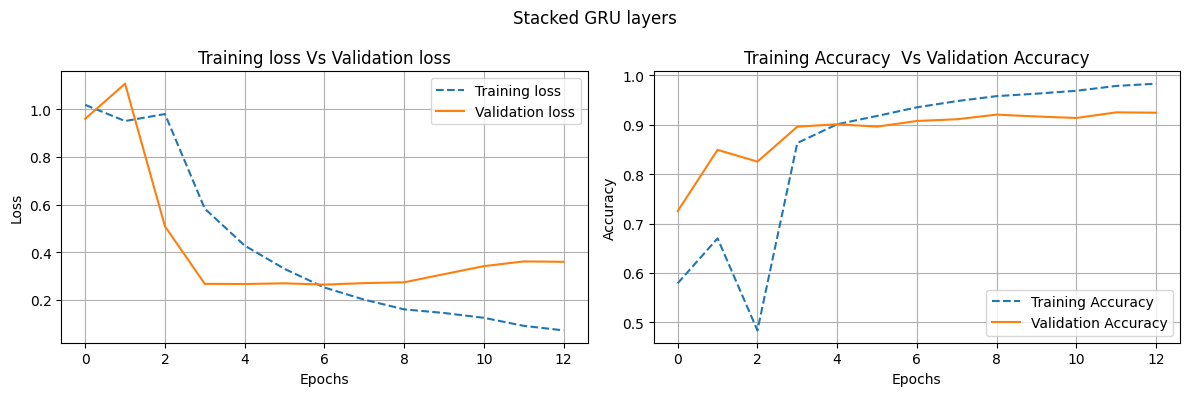

In [ ]:
plot_training(history_v2_stacked_GRU, 'Stacked GRU layers')

998/998 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step
Classification Report:
              precision    recall  f1-score   support

       clean       0.98      0.94      0.96     28856
     flagged       0.46      0.62      0.53      2488
       toxic       0.41      0.72      0.52       571

    accuracy                           0.91     31915
   macro avg       0.62      0.76      0.67     31915
weighted avg       0.93      0.91      0.92     31915
 

Accuracy Score:
0.9098543004856651 



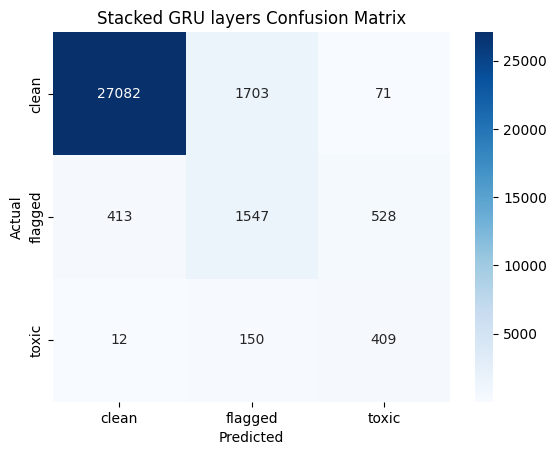

In [ ]:
evaluate_model(model_v2_stacked_GRU, 'Stacked GRU layers')

In [ ]:
save_model(model_v2_stacked_GRU, 'model_v2_stacked_GRU')

### Stacked GRU Funnel

In [ ]:
model_v2_stacked_GRU_funnel = Sequential([
    layers.Embedding(
        input_dim=20000,
        output_dim=128,
        input_length=200
    ),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(32),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model_v2_stacked_GRU_funnel.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history_v2_stacked_GRU_funnel = model_v2_stacked_GRU_funnel.fit(
    X_train_padded,
    y_train,
    epochs = 25,
    batch_size = 64,
    validation_split=.2,
    callbacks = get_callbacks(),
    verbose = 1,
    class_weight = class_weights_dict
)

Epoch 1/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 70s 42ms/step - accuracy: 0.4120 - loss: 1.0675 - val_accuracy: 0.8552 - val_loss: 0.9620 - learning_rate: 0.0010
Epoch 2/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.8273 - loss: 1.0129 - val_accuracy: 0.8500 - val_loss: 0.9717 - learning_rate: 0.0010
Epoch 3/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.8534 - loss: 1.0187 - val_accuracy: 0.8569 - val_loss: 0.9609 - learning_rate: 0.0010
Epoch 4/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 51s 32ms/step - accuracy: 0.8533 - loss: 1.0194 - val_accuracy: 0.8712 - val_loss: 0.9969 - learning_rate: 0.0010
Epoch 5/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 79s 30ms/step - accuracy: 0.8164 - loss: 1.0127 - val_accuracy: 0.8917 - val_loss: 0.9926 - learning_rate: 0.0010
Epoch 6/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.8691 - loss: 1.0257 - val_accuracy: 0.8924 - val_loss: 0.9957 - learning_rate: 0.0010
Epoch 7/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accura

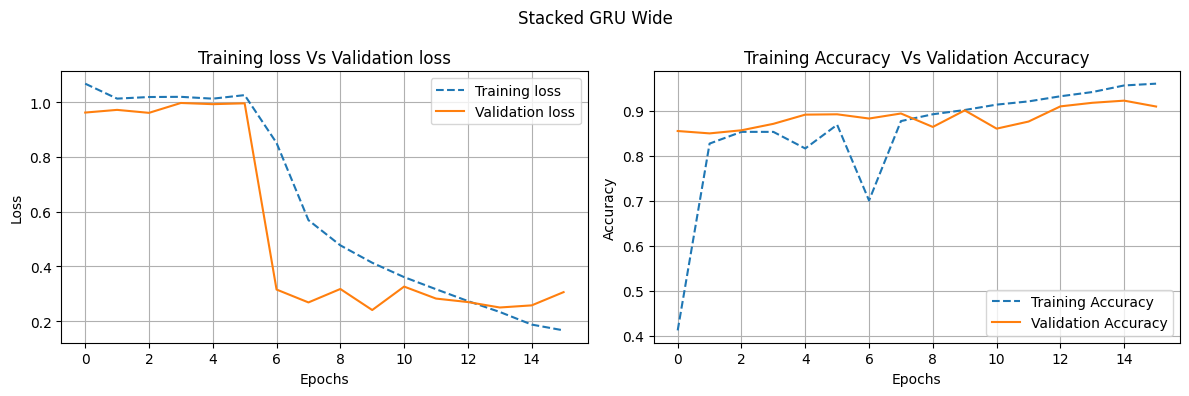

In [ ]:
plot_training(history_v2_stacked_GRU_funnel, 'Stacked GRU Wide')

998/998 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step
Classification Report:
              precision    recall  f1-score   support

       clean       0.99      0.93      0.96     28856
     flagged       0.43      0.63      0.51      2488
       toxic       0.42      0.74      0.53       571

    accuracy                           0.91     31915
   macro avg       0.61      0.77      0.67     31915
weighted avg       0.93      0.91      0.92     31915
 

Accuracy Score:
0.9053736487545041 



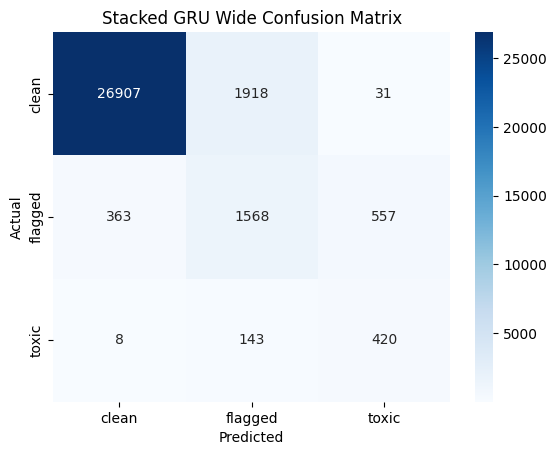

In [ ]:
evaluate_model(model_v2_stacked_GRU_funnel, 'Stacked GRU Wide')

In [ ]:
save_model(model_v2_stacked_GRU_funnel, 'model_v2_stacked_GRU_funnel')

# Phase 4 — Embedding Experiments

## GLOVE - PreTrained

In [ ]:
# Download directly into your Drive folder
!wget -P /content/drive/MyDrive/CMS/ https://nlp.stanford.edu/data/glove.840B.300d.zip
!unzip /content/drive/MyDrive/CMS/glove.840B.300d.zip -d /content/drive/MyDrive/CMS/

--2026-05-12 11:29:47--  https://nlp.stanford.edu/data/glove.840B.300d.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.840B.300d.zip [following]
--2026-05-12 11:29:47--  https://downloads.cs.stanford.edu/nlp/data/glove.840B.300d.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2176768927 (2.0G) [application/zip]
Saving to: ‘/content/drive/MyDrive/CMS/glove.840B.300d.zip’

glove.840B.300d.zip 100%[===================>]   2.03G  5.11MB/s    in 6m 52s  

2026-05-12 11:36:40 (5.03 MB/s) - ‘/content/drive/MyDrive/CMS/glove.840B.300d.zip’ saved [2176768927/2176768927]

Archive:  /conten

In [ ]:
GLOVE_PATH = "/content/drive/MyDrive/CMS/glove.840B.300d.txt"
EMBEDDING_DIM = 300
VOCAB_SIZE = 20000

# Step 1 — load GloVe into a dictionary
embeddings_index = {}

with open(GLOVE_PATH, encoding="utf-8") as f:
    for line in f:
        values = line.split(" ")
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print(f"Loaded {len(embeddings_index):,} word vectors")

# Step 2 — build the embedding matrix
word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

hits, misses = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector
        hits += 1
    else:
        misses += 1

print(f"Converted: {hits:,} | OOV: {misses:,}")

Loaded 2,196,016 word vectors
Converted: 18,926 | OOV: 1,073


### STACKED LSTM FUNNEL (WIDE) ON PRETRAINED GLOVE

In [ ]:
model_v3_glove_lstm_funnel = Sequential([
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=200,
        trainable=False
    ),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(32),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model_v3_glove_lstm_funnel.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history_v3_glove_lstm_funnel = model_v3_glove_lstm_funnel.fit(
    X_train_padded,
    y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.2,
    callbacks=get_callbacks(),
    verbose=1,
    class_weight=class_weights_dict
)

Epoch 1/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - accuracy: 0.5365 - loss: 1.0357 - val_accuracy: 0.9005 - val_loss: 1.0811 - learning_rate: 0.0010
Epoch 2/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 50s 31ms/step - accuracy: 0.4492 - loss: 1.0776 - val_accuracy: 0.0801 - val_loss: 1.0987 - learning_rate: 0.0010
Epoch 3/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.3824 - loss: 1.0853 - val_accuracy: 0.1601 - val_loss: 1.0868 - learning_rate: 0.0010
Epoch 4/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.5986 - loss: 0.9066 - val_accuracy: 0.8174 - val_loss: 0.4168 - learning_rate: 0.0010
Epoch 5/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.8747 - loss: 0.5552 - val_accuracy: 0.9228 - val_loss: 0.2362 - learning_rate: 0.0010
Epoch 6/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.8851 - loss: 0.4960 - val_accuracy: 0.9160 - val_loss: 0.2236 - learning_rate: 0.0010
Epoch 7/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accura

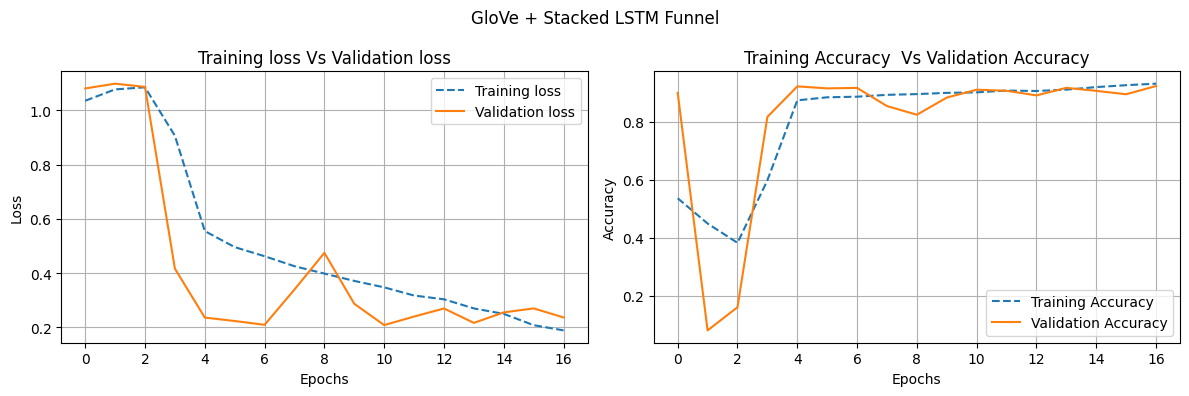

In [ ]:
plot_training(history_v3_glove_lstm_funnel, 'GloVe + Stacked LSTM Funnel')


998/998 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step
Classification Report:
              precision    recall  f1-score   support

       clean       0.99      0.93      0.96     28856
     flagged       0.48      0.74      0.58      2488
       toxic       0.49      0.69      0.58       571

    accuracy                           0.92     31915
   macro avg       0.65      0.79      0.71     31915
weighted avg       0.94      0.92      0.92     31915
 

Accuracy Score:
0.9151182829390568 



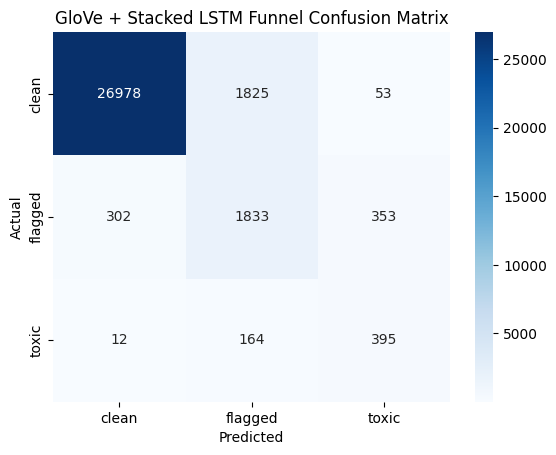

In [ ]:
evaluate_model(model_v3_glove_lstm_funnel, 'GloVe + Stacked LSTM Funnel')


In [ ]:
save_model(model_v3_glove_lstm_funnel, 'model_v3_glove_lstm_funnel')

### GLOVE FINE-TUNED

In [ ]:
model_v3_glove_lstm_funnel.layers[0].trainable = True

In [ ]:
model_v3_glove_lstm_funnel.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # much lower than default 1e-3
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_v3_glove_finetuned = model_v3_glove_lstm_funnel.fit(
    X_train_padded,
    y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.2,
    callbacks=get_callbacks(),
    verbose=1,
    class_weight=class_weights_dict
)

Epoch 1/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 58s 35ms/step - accuracy: 0.9112 - loss: 0.2982 - val_accuracy: 0.8919 - val_loss: 0.2556 - learning_rate: 1.0000e-05
Epoch 2/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 84s 36ms/step - accuracy: 0.9122 - loss: 0.2870 - val_accuracy: 0.8980 - val_loss: 0.2450 - learning_rate: 1.0000e-05
Epoch 3/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.9156 - loss: 0.2793 - val_accuracy: 0.8990 - val_loss: 0.2441 - learning_rate: 1.0000e-05
Epoch 4/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 83s 36ms/step - accuracy: 0.9173 - loss: 0.2695 - val_accuracy: 0.9009 - val_loss: 0.2439 - learning_rate: 1.0000e-05
Epoch 5/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 81s 36ms/step - accuracy: 0.9189 - loss: 0.2654 - val_accuracy: 0.9017 - val_loss: 0.2441 - learning_rate: 1.0000e-05
Epoch 6/25
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 85s 38ms/step - accuracy: 0.9210 - loss: 0.2598 - val_accuracy: 0.9054 - val_loss: 0.2378 - learning_rate: 1.0000e-05
Epoch 7/25
1596/1596 ━━━━━━━━━━━━━━━━━━━

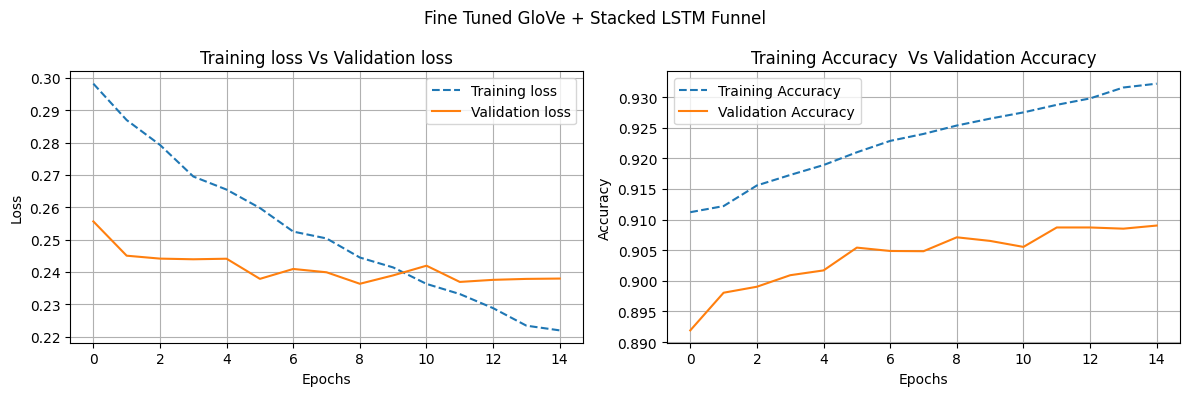

In [ ]:
plot_training(history_v3_glove_finetuned, 'Fine Tuned GloVe + Stacked LSTM Funnel')


998/998 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step
Classification Report:
              precision    recall  f1-score   support

       clean       0.99      0.93      0.96     28856
     flagged       0.46      0.75      0.57      2488
       toxic       0.48      0.68      0.56       571

    accuracy                           0.91     31915
   macro avg       0.64      0.79      0.70     31915
weighted avg       0.94      0.91      0.92     31915
 

Accuracy Score:
0.9095096349678834 



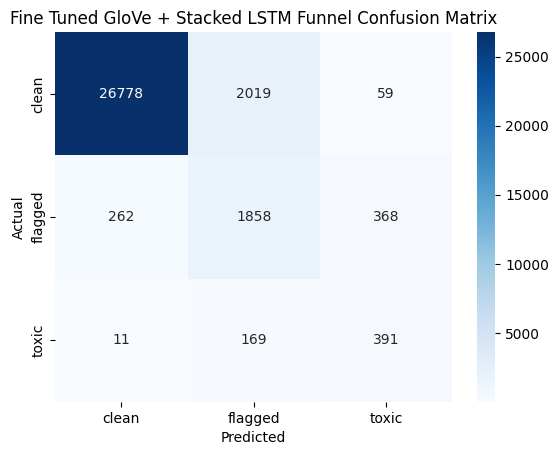

In [ ]:
evaluate_model(model_v3_glove_lstm_funnel, 'Fine Tuned GloVe + Stacked LSTM Funnel')

In [ ]:
save_model(model_v3_glove_lstm_funnel, 'model_v3_glove_fine_tuned_lstm_funnel')

# Inference testing

In [5]:
tokenizer = joblib.load('/content/drive/MyDrive/CMS/tokenizer.joblib')

In [20]:
best_model = keras.models.load_model('/content/drive/MyDrive/CMS/model_v3_glove_lstm_funnel.keras')

In [43]:
LABELS = ['clean', 'flagged', 'toxic']

def predict(text):
  text = preprocess_text(text)
  text_sequence = tokenizer.texts_to_sequences([text])
  padded_text = pad_sequences(text_sequence, maxlen = 200, truncating = 'post', padding='post')
  probs = best_model.predict(padded_text)[0]
  label_idx = int(np.argmax(probs))

  return {
      'label': LABELS[label_idx],
      'confidence': float(probs[label_idx]),
      'scores': {label: round(float(probs[i]), 4) for i, label in enumerate(LABELS)}

  }

test_cases = [
  "This is somewhat inappropriate content",
  "I will kill you and your entire family",
  "I absolutely hate this landlord he is so fuckn stupid. These Rwandan landlords are so slow.'"
]

for text in test_cases:
    result = predict(text)
    print(f"Text    : {text}")
    print(f"Label   : {result['label']} ({result['confidence']:.2%})")
    print(f"Scores  : {result['scores']}")
    print()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
Text    : This is somewhat inappropriate content
Label   : clean (99.83%)
Scores  : {'clean': 0.9983, 'flagged': 0.0016, 'toxic': 0.0}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step
Text    : I will kill you and your entire family
Label   : toxic (91.03%)
Scores  : {'clean': 0.0018, 'flagged': 0.0879, 'toxic': 0.9103}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
Text    : I absolutely hate this landlord he is so fuckn stupid. These Rwandan landlords are so slow.'
Label   : flagged (94.22%)
Scores  : {'clean': 0.0384, 'flagged': 0.9422, 'toxic': 0.0194}

